# Regression evaluation metrics explained

This notebook introduces metrics for comparing numerical predictions with reference scores.
It complements [Classification evaluation metrics explained](classification_evaluation_metrics_explained.qmd).
All data are fictitious. No API calls, model fitting, or external datasets are required.

## Learning goals

- Compute and interpret MSE, RMSE, MAE, and predictive R².
- Distinguish agreement in score values from Pearson and Spearman correlation.
- Explain how large errors, systematic bias, and compressed predictions affect evaluation.

## Background: Predicting numerical scores

Suppose researchers rate how strongly political statements support public investment,
on a scale from **1 (strong opposition)** through **3 (neither support nor opposition)**
to **5 (strong support)**. A model predicts a score for each statement.

We compare the predictions with reference scores representing human annotations.
In research, these should come from held-out texts, separate from those used to train a
model, select prompt examples, or revise coding instructions.
Human reference scores can also contain disagreement and measurement error.

::: {.callout-warning title="What does the scale measure?"}
For error-based metrics and Pearson correlation, we treat the scale as approximately
interval: a difference between 1 and 2 has the same size as a difference between 4 and 5.
This is a measurement assumption, not a property guaranteed by numbering categories.
If only the ordering is defensible, Spearman correlation can assess ordering, but does
not establish agreement on the original ratings.
:::

## Our fictitious data

We use ten reference ratings and ten predictions, all between 1 and 5.
Predictions can contain decimals, as can reference scores obtained by averaging raters.
Here, reference ratings happen to be integers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr, rankdata

y_true = np.array([1, 1, 2, 2, 3, 3, 4, 4, 5, 5], dtype=float)
y_pred = np.array([1, 2, 2, 3, 2, 3, 4, 5, 4, 5], dtype=float)

scores = pd.DataFrame({
    "statement_id": np.arange(1, len(y_true) + 1),
    "reference": y_true,
    "prediction": y_pred,
})
scores

,statement_id,reference,prediction
0,1,1.0,1.0
1,2,1.0,2.0
2,3,2.0,2.0
3,4,2.0,3.0
4,5,3.0,2.0
5,6,3.0,3.0
6,7,4.0,4.0
7,8,4.0,5.0
8,9,5.0,4.0
9,10,5.0,5.0


### Inspecting prediction errors

Define the signed error as prediction minus reference: $e_i = \hat{y}_i - y_i$.
A positive error means overprediction. A negative error means underprediction.

In [2]:
scores["error"] = y_pred - y_true
scores["absolute_error"] = np.abs(scores["error"])
scores["squared_error"] = scores["error"] ** 2
scores

,statement_id,reference,prediction,error,absolute_error,squared_error
0,1,1.0,1.0,0.0,0.0,0.0
1,2,1.0,2.0,1.0,1.0,1.0
2,3,2.0,2.0,0.0,0.0,0.0
3,4,2.0,3.0,1.0,1.0,1.0
4,5,3.0,2.0,-1.0,1.0,1.0
5,6,3.0,3.0,0.0,0.0,0.0
6,7,4.0,4.0,0.0,0.0,0.0
7,8,4.0,5.0,1.0,1.0,1.0
8,9,5.0,4.0,-1.0,1.0,1.0
9,10,5.0,5.0,0.0,0.0,0.0


Averaging signed errors can hide mistakes because positive and negative errors cancel.
The metrics below measure different aspects of performance.

## Error-based metrics

### Mean squared error (MSE)

Square each error, then average:

$$\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2.$$

Squaring makes larger errors contribute disproportionately: an error of 2 contributes 4,
whereas an error of 1 contributes 1. MSE is measured in **squared scale points**.
Lower is better, and 0 means every prediction equals its reference score.

In [3]:
mse_manual = np.mean((y_pred - y_true) ** 2)
mse = mean_squared_error(y_true, y_pred)
print("MSE:", mse)

MSE: 0.5


Five predictions are off by one point and five are exact, so MSE is 0.5.

### Root mean squared error (RMSE)

Take the square root of MSE:

$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2}.$$

RMSE is back in **scale points**, making it easier to interpret than MSE.
It retains the emphasis on larger errors. Lower is better, with a best value of 0.
It is not the arithmetic mean of the absolute errors.

In [4]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 0.7071067811865476


Here RMSE is about 0.71 scale points. MSE and RMSE rank competing predictions in exactly
the same order when evaluated on the same cases: taking a square root preserves their ordering.

### Mean absolute error (MAE)

Take the absolute value of each error, then average:

$$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}|\hat{y}_i-y_i|.$$

MAE measures the **average absolute distance in scale points**.
An error of 2 contributes twice as much as an error of 1.
Lower is better, with a best value of 0.

In [5]:
mae = mean_absolute_error(y_true, y_pred)
print("MAE:", mae)

MAE: 0.5


Here MAE is 0.5: predictions differ from their reference scores by half a scale point on average.
On the same cases, RMSE is at least as large as MAE.

## Predictive R²: Comparison with a mean benchmark

R² compares the squared prediction errors with the squared deviations of the reference
scores from their own mean:

$$R^2 = 1 - \frac{\sum_i(y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2}.$$

For nonconstant reference scores:

- **1:** predictions match every reference score.
- **0:** the squared-error total equals that of predicting the evaluation-set reference mean for every case.
- **Below 0:** predictions have more squared error than that mean benchmark.

In [6]:
reference_mean = y_true.mean()
mean_predictions = np.full_like(y_true, reference_mean)
r2 = r2_score(y_true, y_pred)
print("Reference mean:", reference_mean)
print("MSE of mean benchmark:", mean_squared_error(y_true, mean_predictions))
print("R² of our predictions:", r2)
print("R² of mean benchmark:", r2_score(y_true, mean_predictions))

Reference mean: 3.0
MSE of mean benchmark: 2.0
R² of our predictions: 0.75
R² of mean benchmark: 0.0


Here the mean benchmark's MSE is 2 and our predictions' MSE is 0.5.
Thus R² is 0.75: a 75% reduction in squared error relative to this benchmark.

::: {.callout-warning title="R² can be negative"}
Predictive R² is not restricted to 0–1. It also is not generally the squared correlation
between arbitrary predictions and reference values. That equality holds in special
settings, such as in-sample ordinary least squares with an intercept.
:::

The evaluation-set mean is the mathematical reference in R². It would be unavailable for
new unlabeled cases. A deployable constant baseline should estimate its value from training
data instead. If reference scores are constant, R²'s denominator is zero; scikit-learn
replaces nonfinite results by default unless `force_finite=False` is specified.

## Correlation metrics

### Pearson correlation (pearson_r)

Pearson's $r$ measures **linear association**: do higher reference scores tend to coincide
with proportionally higher predictions?

$$r = \frac{\sum_i(y_i-\bar{y})(\hat{y}_i-\bar{\hat{y}})}
{\sqrt{\sum_i(y_i-\bar{y})^2\sum_i(\hat{y}_i-\bar{\hat{y}})^2}}.$$

- **+1:** a perfect increasing linear relationship.
- **0:** no linear association, though a nonlinear relationship may exist.
- **−1:** a perfect decreasing linear relationship.

In [7]:
pearson_r = pearsonr(y_true, y_pred).statistic
print("Pearson r:", pearson_r)

Pearson r: 0.8702852691526739


For predictions on the same scale and in the same direction, we want a correlation near +1.
However, adding a constant to predictions or multiplying them by a positive constant does
not change their Pearson correlation. Large systematic errors can therefore coexist with
perfect correlation.

### Spearman rank correlation (spearman_r)

Spearman's correlation, often written $\rho$, measures **association in rank order**.
It is Pearson correlation computed on the ranks of the two variables:

$$\rho = \operatorname{cor}(\operatorname{rank}(y),\operatorname{rank}(\hat{y})).$$

It ranges from −1 to +1. A value of +1 means identical rank patterns, while −1 means
reversed rank patterns. Zero indicates no rank correlation, not necessarily no relationship.
A strictly increasing transformation preserves ranks, even when it is nonlinear.

In [8]:
spearman_r = spearmanr(y_true, y_pred).statistic
print("Spearman correlation:", spearman_r)

# Repeated values receive the average of their tied rank positions.
ranks = pd.DataFrame({
    "reference": y_true,
    "reference_rank": rankdata(y_true),
    "prediction": y_pred,
    "prediction_rank": rankdata(y_pred),
})
ranks

Spearman correlation: 0.8679416943609326


,reference,reference_rank,prediction,prediction_rank
0,1.0,1.5,1.0,1.0
1,1.0,1.5,2.0,3.0
2,2.0,3.5,2.0,3.0
3,2.0,3.5,3.0,5.5
4,3.0,5.5,2.0,3.0
5,3.0,5.5,3.0,5.5
6,4.0,7.5,4.0,7.5
7,4.0,7.5,5.0,9.5
8,5.0,9.5,4.0,7.5
9,5.0,9.5,5.0,9.5


Ties are common on a five-point scale. `spearmanr()` handles them through average ranks.
Both SciPy functions also return p-values; here we focus on the correlation coefficients
as descriptive evaluation measures. A small p-value would not demonstrate accurate ratings.

::: {.callout-warning title="Correlation is not agreement"}
Pearson and Spearman assess association, not closeness to the reference scores.
Report an error metric alongside them when recovering the actual score values matters.
Both correlations are undefined when either input is constant.
:::

## A compact evaluation report

This helper names all six metrics consistently. It returns `NaN` for correlations of
constant inputs rather than attempting to interpret an undefined value.
The examples use complete, aligned arrays with at least two observations and nonconstant
reference scores.

In [9]:
def regression_report(reference, prediction):
    reference = np.asarray(reference, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    mse = mean_squared_error(reference, prediction)
    variable = np.ptp(reference) > 0 and np.ptp(prediction) > 0
    return pd.Series({
        "mse": mse,
        "rmse": np.sqrt(mse),
        "mae": mean_absolute_error(reference, prediction),
        "r2": r2_score(reference, prediction, force_finite=False),
        "pearson_r": pearsonr(reference, prediction).statistic if variable else np.nan,
        "spearman_r": spearmanr(reference, prediction).statistic if variable else np.nan,
    })

regression_report(y_true, y_pred).round(3)

mse           0.500
rmse          0.707
mae           0.500
r2            0.750
pearson_r     0.870
spearman_r    0.868
dtype: float64

| Metric | Main question | Better performance |
|---|---|---|
| MSE | How large are squared errors? | Lower, best 0 |
| RMSE | How large are errors in scale units, emphasizing large errors? | Lower, best 0 |
| MAE | What is the average absolute error in scale points? | Lower, best 0 |
| R² | How much does squared error improve over the reference-mean benchmark? | Higher, best 1 |
| Pearson r | How strong is increasing linear association? | Closer to +1, but check agreement |
| Spearman r | How well is increasing rank order preserved? | Closer to +1, but check agreement |

## Comparing prediction patterns

Every reference and predicted value below remains on the 1–5 scale.
We construct the patterns deliberately to illustrate metrics, not to simulate a fitted model.

In [10]:
patterns = {
    "Exact": y_true.copy(),
    "Small errors": y_pred.copy(),
    "Compressed": 3 + 0.5 * (y_true - 3),
    "Nonlinear, same ranks": 1 + 4 * ((y_true - 1) / 4) ** 2,
    "Reversed": 6 - y_true,
    "Constant mean": mean_predictions,
}

comparison = pd.DataFrame({
    name: regression_report(y_true, prediction)
    for name, prediction in patterns.items()
}).T
comparison.round(3)

,mse,rmse,mae,r2,pearson_r,spearman_r
Exact,0.000,0.000,0.0,1.000,1.000,1.000
Small errors,0.500,0.707,0.5,0.750,0.870,0.868
Compressed,0.500,0.707,0.6,0.750,1.000,1.000
"Nonlinear, same ranks",0.425,0.652,0.5,0.788,0.959,1.000
Reversed,8.000,2.828,2.4,-3.000,-1.000,-1.000
Constant mean,2.000,1.414,1.2,0.000,NaN,NaN


### Predicted versus reference scores

The dashed diagonal represents exact agreement. The same axis limits make plots comparable.
Overlapping observations share a marker, so a plotted point can represent multiple statements.

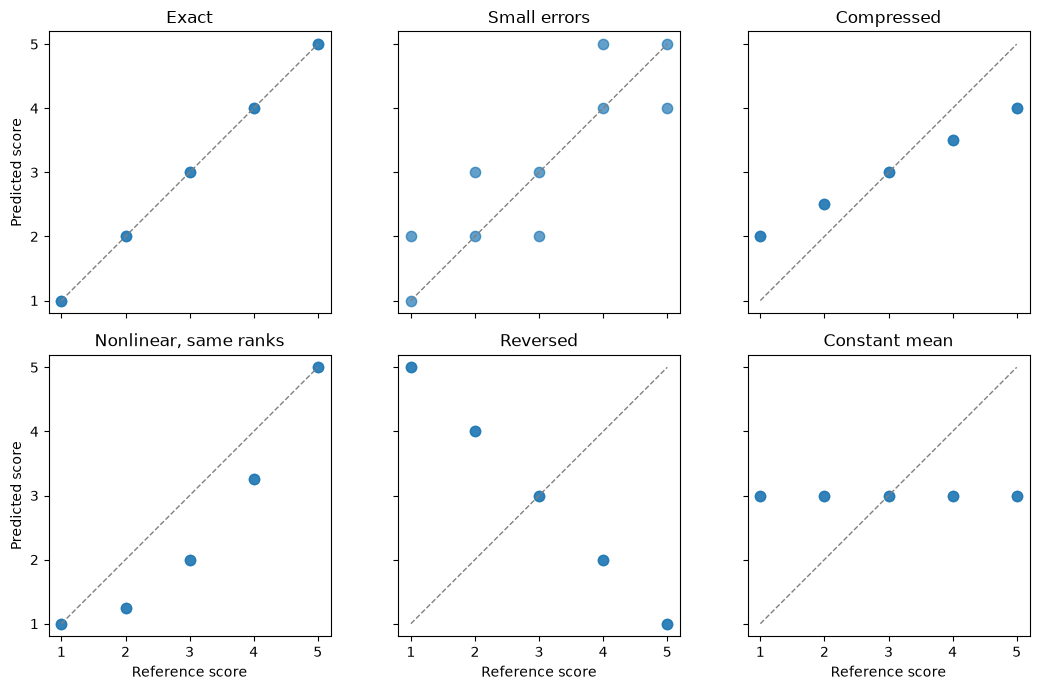

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True, sharey=True)
for ax, (name, prediction) in zip(axes.flat, patterns.items()):
    ax.scatter(y_true, prediction, s=55, alpha=0.7)
    ax.plot([1, 5], [1, 5], "--", color="gray", linewidth=1)
    ax.set_title(name)
    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(0.8, 5.2)
    ax.set_xticks(range(1, 6))
    ax.set_yticks(range(1, 6))
    ax.set_aspect("equal", adjustable="box")
for ax in axes[-1]:
    ax.set_xlabel("Reference score")
for ax in axes[:, 0]:
    ax.set_ylabel("Predicted score")
fig.tight_layout()
plt.show()

**Discuss before reading the interpretation:**
Which patterns preserve ordering? Which recover the actual values? Why might a model
that avoids extreme ratings look good by one metric and poor by another?

<details>
<summary>Example interpretation</summary>

- **Exact:** zero errors, R² = 1, and both correlations = 1.
- **Compressed:** perfect Pearson and Spearman correlations, but predictions pull extreme
  ratings toward the midpoint. MAE = 0.6 and R² = 0.75.
- **Nonlinear, same ranks:** Spearman = 1 but Pearson is below 1. The ordering remains
  unchanged while distances between scores change.
- **Reversed:** both correlations = −1 and R² = −3. Opposition and support are confused.
- **Constant mean:** R² = 0. Correlations are undefined because predictions have no variation.

</details>

## Exercise: One large error versus several small errors

Before running the cell, predict which error pattern each metric penalizes more.
Both patterns stay within the scale bounds.

In [12]:
several_small = y_true.copy()
several_small[:4] += 1  # Four errors of one point each.

one_large = y_true.copy()
one_large[0] = 5       # One error of four points.

pd.DataFrame({
    "Four small errors": regression_report(y_true, several_small),
    "One large error": regression_report(y_true, one_large),
}).T.round(3)

,mse,rmse,mae,r2,pearson_r,spearman_r
Four small errors,0.4,0.632,0.4,0.8,0.971,0.975
One large error,1.6,1.265,0.4,0.2,0.626,0.604


1. Explain why MAE is the same while MSE and RMSE differ.
2. Copy one prediction array and correct an error. Predict how the error metrics will change.
3. Propose a research situation where a four-point error would be especially consequential.

In [13]:
# TODO: correct one prediction, keeping all scores between 1 and 5.
modified_predictions = one_large.copy()
# TODO: call regression_report(y_true, modified_predictions).

<details>
<summary>Example solution</summary>

Both patterns have a total absolute error of 4, so MAE = 0.4.
Four one-point errors have a total squared error of 4; one four-point error contributes 16.
Thus MSE is 0.4 versus 1.6, and RMSE is about 0.63 versus 1.26.

In [14]:
corrected_predictions = one_large.copy()
corrected_predictions[0] = y_true[0]
regression_report(y_true, corrected_predictions).round(3)

mse           0.0
rmse          0.0
mae           0.0
r2            1.0
pearson_r     1.0
spearman_r    1.0
dtype: float64

Correcting the only error produces exact agreement.

</details>

## Exercise: Perfect correlation with systematic overprediction

Use a subset with reference scores no higher than 4, so adding one point keeps all
predictions on the 1–5 scale.

In [15]:
reference_subset = y_true[y_true <= 4]
shifted_predictions = reference_subset + 1

# TODO: predict all six metrics before running the report.
# regression_report(reference_subset, shifted_predictions).round(3)

<details>
<summary>Example solution</summary>

In [16]:
regression_report(reference_subset, shifted_predictions).round(3)

mse           1.0
rmse          1.0
mae           1.0
r2            0.2
pearson_r     1.0
spearman_r    1.0
dtype: float64

MSE, RMSE, and MAE are all 1. Both correlations are 1, yet every score is too high.
R² = 0.2. Correlation alone would conceal this systematic overprediction.

</details>

## Choosing metrics for research

Use MAE to communicate average error in scale points. Add RMSE when larger errors deserve
extra weight. R² supplies a squared-error comparison with a mean benchmark.
Pearson and Spearman describe association and ordering, respectively.

Inspect plots and individual errors alongside scores. If comparing groups, also inspect
signed errors within each group: overall metrics can conceal systematic over- or underprediction.
Report which cases were evaluated and how missing or invalid predictions were handled.
